##               **RESUME SCREENING PREDICTION**




In [100]:
# Importing the data sets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.svm import SVC
from xgboost import XGBClassifier

  ## **1. Upload The Dataset**



In [101]:
df = pd.read_csv("ai_resume_screening.csv")
df

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
0,6,84.7,Bachelors,7,234,158,No
1,3,59.1,Masters,5,502,77,No
2,12,100.0,Masters,12,753,381,Yes
3,14,66.8,High School,8,529,407,Yes
4,10,99.6,Bachelors,10,754,331,Yes
...,...,...,...,...,...,...,...
29995,9,77.4,Bachelors,13,691,434,Yes
29996,5,77.8,Bachelors,9,473,149,No
29997,1,64.6,Bachelors,7,247,82,No
29998,7,94.8,Bachelors,12,584,409,Yes


In [102]:
df.columns

Index(['years_experience', 'skills_match_score', 'education_level',
       'project_count', 'resume_length', 'github_activity', 'shortlisted'],
      dtype='object')

In [103]:
df.head()

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
0,6,84.7,Bachelors,7,234,158,No
1,3,59.1,Masters,5,502,77,No
2,12,100.0,Masters,12,753,381,Yes
3,14,66.8,High School,8,529,407,Yes
4,10,99.6,Bachelors,10,754,331,Yes


In [104]:
df.tail()

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
29995,9,77.4,Bachelors,13,691,434,Yes
29996,5,77.8,Bachelors,9,473,149,No
29997,1,64.6,Bachelors,7,247,82,No
29998,7,94.8,Bachelors,12,584,409,Yes
29999,14,77.3,Masters,25,694,790,Yes


In [105]:
df.shape

(30000, 7)

In [106]:
df.describe()

,years_experience,skills_match_score,project_count,resume_length,github_activity
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,7.506567,73.682653,10.646267,572.584700,325.260667
std,4.624104,16.765909,4.634047,178.709918,159.951803
min,0.000000,0.500000,0.000000,150.000000,0.000000
25%,3.750000,62.100000,7.000000,441.000000,202.000000
50%,7.000000,74.300000,10.000000,574.000000,321.000000
75%,12.000000,86.500000,14.000000,709.000000,443.000000
max,15.000000,100.000000,25.000000,900.000000,842.000000


In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   years_experience    30000 non-null  int64  
 1   skills_match_score  30000 non-null  float64
 2   education_level     30000 non-null  object 
 3   project_count       30000 non-null  int64  
 4   resume_length       30000 non-null  int64  
 5   github_activity     30000 non-null  int64  
 6   shortlisted         30000 non-null  object 
dtypes: float64(1), int64(4), object(2)
memory usage: 1.6+ MB


In [108]:
df.dtypes

,0
years_experience,int64
skills_match_score,float64
education_level,object
project_count,int64
resume_length,int64
github_activity,int64
shortlisted,object


         
 #       **2. Data Cleaning**

In [109]:
df.isnull().sum()

,0
years_experience,0
skills_match_score,0
education_level,0
project_count,0
resume_length,0
github_activity,0
shortlisted,0


In [110]:
df.duplicated().sum()

np.int64(0)

#      **3. Exploratory Data Analysis**

In [111]:
df['shortlisted'].value_counts()

,count
shortlisted,
Yes,20966
No,9034


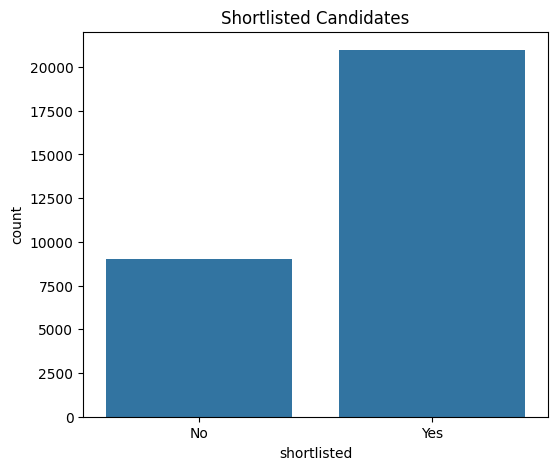

In [112]:
# To show the count of shortlisted candidates
plt.figure(figsize=(6,5))

sns.countplot(x='shortlisted',data=df)

plt.title("Shortlisted Candidates")
plt.show()

In [113]:
x=df["education_level"].value_counts()
x

,count
education_level,
Bachelors,13461
Masters,10524
PhD,3024
High School,2991


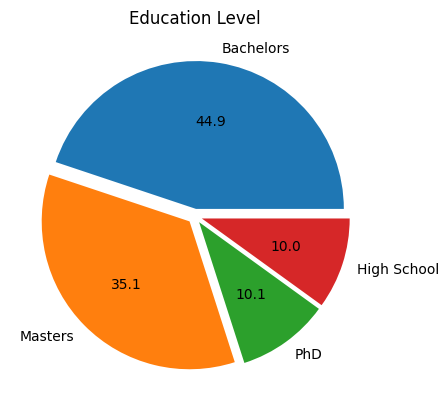

In [114]:
# Education level
plt.pie(x,labels=x.index,autopct='%1.1f',explode=[0.05,0.05,0.05,0.05])

plt.title("Education Level")
plt.show()

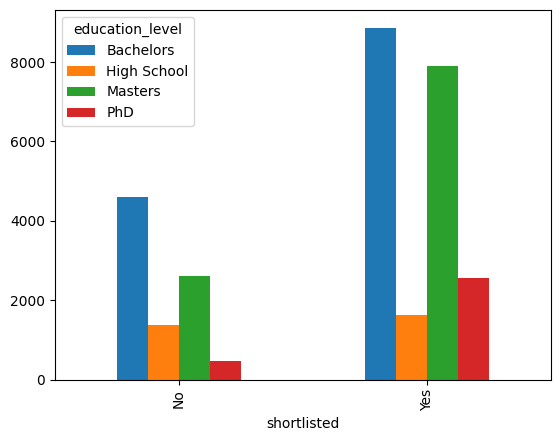

In [115]:
#shortlisted based on the Education Level

pd.crosstab(df["shortlisted"],df["education_level"]).plot(kind="bar")
plt.show()

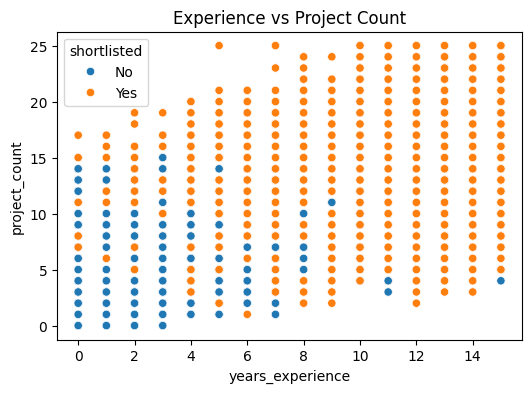

In [116]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x='years_experience',
    y='project_count',
    hue='shortlisted',
    data=df
)

plt.title("Experience vs Project Count")
plt.show()

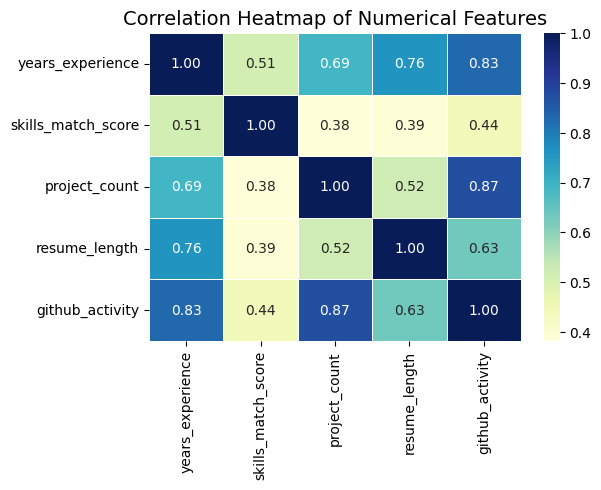

In [117]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='YlGnBu',
            linewidths=0.5,
            fmt='.2f')
plt.title("Correlation Heatmap of Numerical Features", fontsize=14)
plt.show()

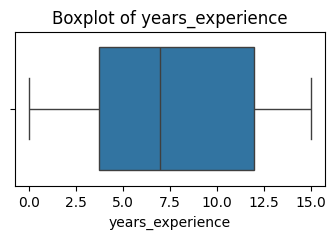

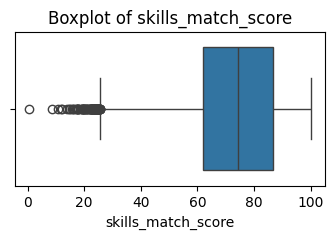

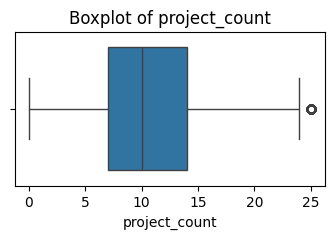

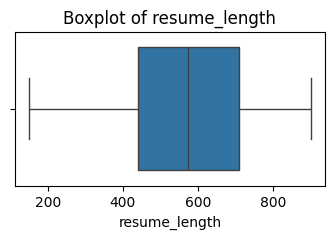

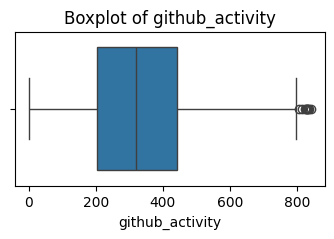

In [118]:
numerical_columns = [
    'years_experience',
    'skills_match_score',
    'project_count',
    'resume_length',
    'github_activity'
]

for col in numerical_columns:
    plt.figure(figsize=(4,2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

#4.One Hot Encoding

In [119]:
oe=OneHotEncoder()
df=pd.get_dummies(df,columns=["education_level"],drop_first=True,dtype=int)
df


,years_experience,skills_match_score,project_count,resume_length,github_activity,shortlisted,education_level_High School,education_level_Masters,education_level_PhD
0,6,84.7,7,234,158,No,0,0,0
1,3,59.1,5,502,77,No,0,1,0
2,12,100.0,12,753,381,Yes,0,1,0
3,14,66.8,8,529,407,Yes,1,0,0
4,10,99.6,10,754,331,Yes,0,0,0
...,...,...,...,...,...,...,...,...,...
29995,9,77.4,13,691,434,Yes,0,0,0
29996,5,77.8,9,473,149,No,0,0,0
29997,1,64.6,7,247,82,No,0,0,0
29998,7,94.8,12,584,409,Yes,0,0,0


# 5. Label Encoding




In [120]:
le = LabelEncoder()

In [121]:
df["shortlisted"]=le.fit_transform(df["shortlisted"])
df
# No--->0
# Yes--->1

,years_experience,skills_match_score,project_count,resume_length,github_activity,shortlisted,education_level_High School,education_level_Masters,education_level_PhD
0,6,84.7,7,234,158,0,0,0,0
1,3,59.1,5,502,77,0,0,1,0
2,12,100.0,12,753,381,1,0,1,0
3,14,66.8,8,529,407,1,1,0,0
4,10,99.6,10,754,331,1,0,0,0
...,...,...,...,...,...,...,...,...,...
29995,9,77.4,13,691,434,1,0,0,0
29996,5,77.8,9,473,149,0,0,0,0
29997,1,64.6,7,247,82,0,0,0,0
29998,7,94.8,12,584,409,1,0,0,0


#6. Seperating the Feature and Target column


In [122]:
x=df.drop("shortlisted",axis=1)
x


,years_experience,skills_match_score,project_count,resume_length,github_activity,education_level_High School,education_level_Masters,education_level_PhD
0,6,84.7,7,234,158,0,0,0
1,3,59.1,5,502,77,0,1,0
2,12,100.0,12,753,381,0,1,0
3,14,66.8,8,529,407,1,0,0
4,10,99.6,10,754,331,0,0,0
...,...,...,...,...,...,...,...,...
29995,9,77.4,13,691,434,0,0,0
29996,5,77.8,9,473,149,0,0,0
29997,1,64.6,7,247,82,0,0,0
29998,7,94.8,12,584,409,0,0,0


In [123]:
y=df["shortlisted"]
y

,shortlisted
0,0
1,0
2,1
3,1
4,1
...,...
29995,1
29996,0
29997,0
29998,1


#7. Train Test Split

In [124]:
train_x,test_x,train_y,test_y=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)


#8. Standard Scalling

 generally scaling is  not required for tree algorithms



In [125]:
scaler=StandardScaler()

In [126]:
train_x_scaled = scaler.fit_transform(train_x)
test_x_scaled = scaler.transform(test_x)

#9. SMOTE

In [159]:
from imblearn.over_sampling import SMOTE
df['shortlisted'].value_counts()
smote=SMOTE(random_state=42)
train_x_smote,train_y_smote = smote.fit_resample(train_x_scaled, train_y)
train_x_smote_raw,train_y_smote_raw = smote.fit_resample(train_x,train_y)

##**10. Model** **Training**

## 10.1. Logistic Regression

In [147]:
lr = LogisticRegression()
lr.fit(train_x_smote, train_y_smote)
lr_pred = lr.predict(test_x_scaled)
lr_accuracy=accuracy_score(test_y, lr_pred)*100
lr_precision=precision_score(test_y, lr_pred)*100
lr_recall=recall_score(test_y, lr_pred)*100
lr_f1_score=f1_score(test_y, lr_pred)*100
print("Accuracy :", lr_accuracy)
print("Precision:",lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1_score)

print("\nClassification Report")
print(classification_report(test_y, lr_pred))

Accuracy : 89.18333333333334
Precision: 95.48254620123203
Recall   : 88.71929406153113
F1 Score : 91.97675856100878

Classification Report
              precision    recall  f1-score   support

           0       0.78      0.90      0.83      1807
           1       0.95      0.89      0.92      4193

    accuracy                           0.89      6000
   macro avg       0.87      0.89      0.88      6000
weighted avg       0.90      0.89      0.89      6000



# 10.2. Decision Tree





In [148]:
dt = DecisionTreeClassifier(criterion="entropy")
dt.fit(train_x_smote_raw, train_y_smote_raw)
dt_pred = dt.predict(test_x)
dt_accuracy=accuracy_score(test_y, dt_pred)*100
dt_precision=precision_score(test_y, dt_pred)*100
dt_recall=recall_score(test_y, dt_pred)*100
dt_f1_score=f1_score(test_y, dt_pred)*100
print("Accuracy :", dt_accuracy)
print("Precision:",dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1_score)

print("\nClassification Report")
print(classification_report(test_y, dt_pred))

Accuracy : 86.6
Precision: 91.68511685116852
Recall   : 88.88623896971143
F1 Score : 90.26398643739404

Classification Report
              precision    recall  f1-score   support

           0       0.76      0.81      0.79      1807
           1       0.92      0.89      0.90      4193

    accuracy                           0.87      6000
   macro avg       0.84      0.85      0.84      6000
weighted avg       0.87      0.87      0.87      6000



##10.3. RandomForest

In [149]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(train_x_smote_raw, train_y_smote_raw)
rf_pred=rf.predict(test_x)
rf_accuracy=accuracy_score(test_y,rf_pred)*100
rf_precision=precision_score(test_y, rf_pred)*100
rf_recall=recall_score(test_y, rf_pred)*100
rf_f1_score=f1_score(test_y, rf_pred)*100
print("Accuracy :", rf_accuracy)
print("Precision:",rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1_score)

print("\nClassification Report")
print(classification_report(test_y, rf_pred))

Accuracy : 89.61666666666666
Precision: 93.70714985308521
Recall   : 91.27116622943
F1 Score : 92.47311827956989

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.86      0.83      1807
           1       0.94      0.91      0.92      4193

    accuracy                           0.90      6000
   macro avg       0.87      0.89      0.88      6000
weighted avg       0.90      0.90      0.90      6000



#10.4.SVM

In [150]:
svm = SVC(kernel='rbf')

svm.fit(train_x_smote, train_y_smote)

svm_pred = svm.predict(test_x_scaled)

svm_accuracy = accuracy_score(test_y, svm_pred)*100
svm_precision = precision_score(test_y, svm_pred)*100
svm_recall = recall_score(test_y, svm_pred)*100
svm_f1_score = f1_score(test_y, svm_pred)*100

print("SVM Accuracy :", svm_accuracy)
print("SVM Precision :", svm_precision)
print("SVM Recall:", svm_recall)
print("SVM F1_score :", svm_f1_score)

SVM Accuracy : 88.91666666666667
SVM Precision : 96.03340292275574
SVM Recall: 87.76532315764369
SVM F1_score : 91.71339563862928


#10.5. XGBoost

In [151]:
!pip install xgboost

In [152]:
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(train_x_smote_raw, train_y_smote_raw)

xgb_pred = xgb.predict(test_x)

xgb_accuracy = accuracy_score(test_y, xgb_pred)*100
xgb_precision = precision_score(test_y, xgb_pred)*100
xgb_recall = recall_score(test_y, xgb_pred)*100
xgb_f1_score = f1_score(test_y, xgb_pred)*100

print("XGBoost Accuracy :", xgb_accuracy)
print("XGBoost Precision :", xgb_precision)
print("XGBoost Recall:", xgb_recall)
print("XGBoostF1_score :", xgb_f1_score)

XGBoost Accuracy : 89.75
XGBoost Precision : 94.2602671944582
XGBoost Recall: 90.86572859527784
XGBoostF1_score : 92.53187613843352


##11. Model Comparision





In [153]:
comparison = pd.DataFrame({"Model":["Logistic Regression","Decision Tree","Random Forest","SVM","XGBoost"],
                           "Accuracy":[lr_accuracy,dt_accuracy,rf_accuracy,svm_accuracy,xgb_accuracy],
                           "Precision":[lr_precision,dt_precision,rf_precision,svm_precision,xgb_precision],
                           "Recall":[lr_recall,dt_recall,rf_recall,svm_recall,xgb_recall],
                           "F1_score":[lr_f1_score,dt_f1_score,rf_f1_score,svm_f1_score,xgb_f1_score]})
comparison

,Model,Accuracy,Precision,Recall,F1_score
0,Logistic Regression,89.183333,95.482546,88.719294,91.976759
1,Decision Tree,86.600000,91.685117,88.886239,90.263986
2,Random Forest,89.616667,93.707150,91.271166,92.473118
3,SVM,88.916667,96.033403,87.765323,91.713396
4,XGBoost,89.750000,94.260267,90.865729,92.531876


#12. Accuracy, Precision, Recall, F1 score comparision Graph

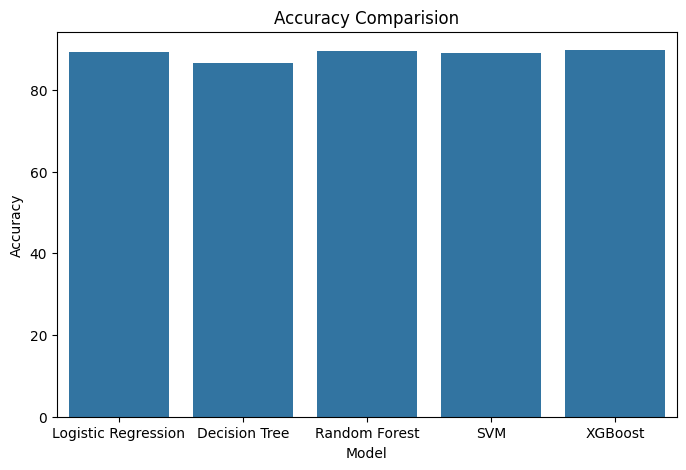

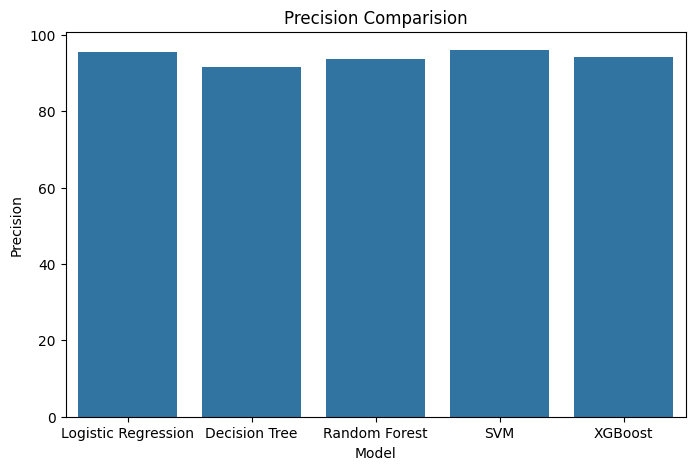

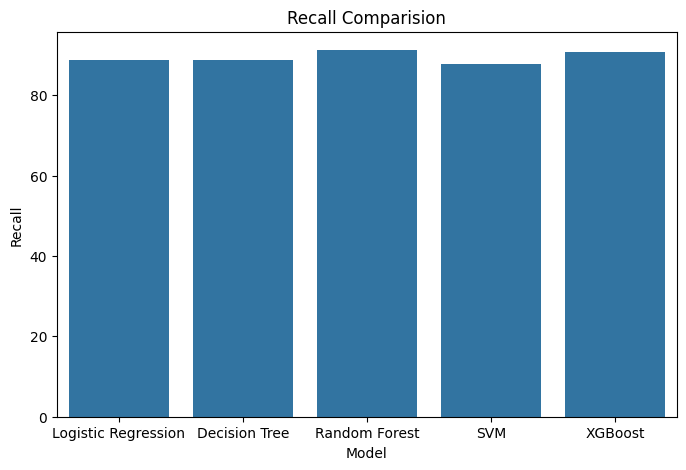

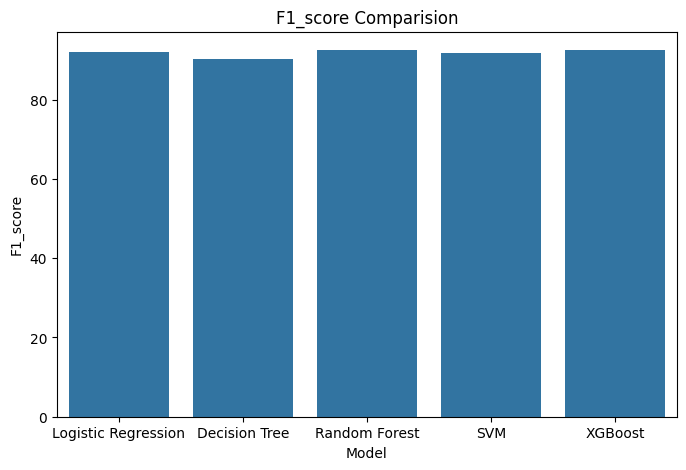

In [154]:
a=["Accuracy","Precision","Recall","F1_score"]
for i in a:
  plt.figure(figsize=(8,5))

  sns.barplot(data=comparison,x="Model",y=i)
  plt.title(f"{i} Comparision")
  plt.show()

# 13. Final model with highest Accuracy

In [155]:
print("Final Model Accuracy :\n", comparison.loc[comparison["Accuracy"].idxmax()])

Final Model Accuracy :
 Model          XGBoost
Accuracy         89.75
Precision    94.260267
Recall       90.865729
F1_score     92.531876
Name: 4, dtype: object


#14. Take  XGBoost
Because XGBoost give highest Accuracy



In [156]:
cm=confusion_matrix(test_y,xgb_pred)
cm

array([[1575,  232],
       [ 383, 3810]])

Text(50.722222222222214, 0.5, 'Predicted')

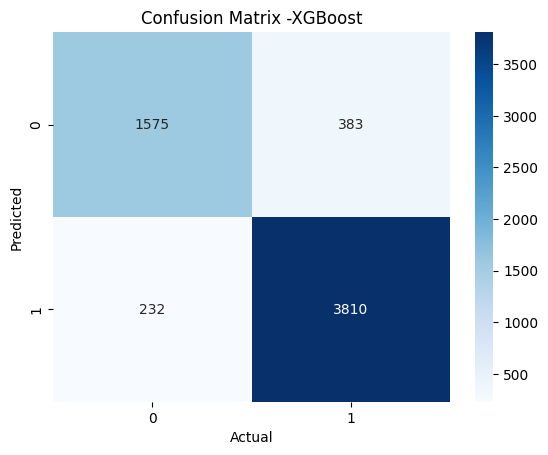

In [157]:
sns.heatmap(cm.T,annot=True,cmap="Blues",fmt="d")
plt.title("Confusion Matrix -XGBoost")
plt.xlabel("Actual")
plt.ylabel("Predicted")

#15. Feature Importance



In [158]:

pd.DataFrame({"Features":x.columns,"importance":rf.feature_importances_})



,Features,importance
0,years_experience,0.283323
1,skills_match_score,0.142593
2,project_count,0.156621
3,resume_length,0.112787
4,github_activity,0.263132
5,education_level_High School,0.003847
6,education_level_Masters,0.022125
7,education_level_PhD,0.015570
